# Eje 3b — Volatilidad y coberturas

Derivados Financieros — QUANt UCEMA

Estrategias que compran/venden incertidumbre, y las que protegen un stock.

**Plan del notebook:**
1. Straddle y Strangle (long / short)
2. Iron Condor e Iron Butterfly
3. Covered Call y Protective Put
4. Collar
5. Resumen

*(Los casos protectivos / straddle de 01c son teasers; acá está el catálogo completo.)*


In [1]:
import sys
sys.path.append('../../..')

import numpy as np
import matplotlib.pyplot as plt
from Codigo.analytics.payoffs import (
    payoff_straddle, payoff_strangle,
    payoff_short_straddle, payoff_short_strangle,
    payoff_iron_condor, payoff_iron_butterfly,
    payoff_covered_call, payoff_protective_put, payoff_collar,
)
from Codigo.pricing import precio_estrategia_nombre
from Codigo.utils.plots import plot_payoff

S0, T, r, sigma, div = 100.0, 0.5, 0.05, 0.25, 0.0
K = 100.0
# Strangle OTM en Codigo: Call(K_call) + Put(K_put) con K_call > K_put
K_put, K_call = 85.0, 115.0
# Iron condor: K1 < K2 < K3 < K4
K1, K2, K3, K4 = 85.0, 95.0, 105.0, 115.0


## 1) Straddle y Strangle

- **Long Straddle**: long call + long put mismo $K$ (ATM). Compra de volatilidad; break-evens lejos.
- **Long Strangle**: put OTM $K_{\mathrm{put}}$ + call OTM $K_{\mathrm{call}}$ ($K_{\mathrm{call}}>K_{\mathrm{put}}$). Más barato; necesita movimiento mayor.
- **Short** = vender volatilidad (crédito; riesgo de cola).

En `Codigo`, `payoff_strangle(S, K1, K2)` = Call($K_1$) + Put($K_2$) con convención OTM $K_1>K_2$.


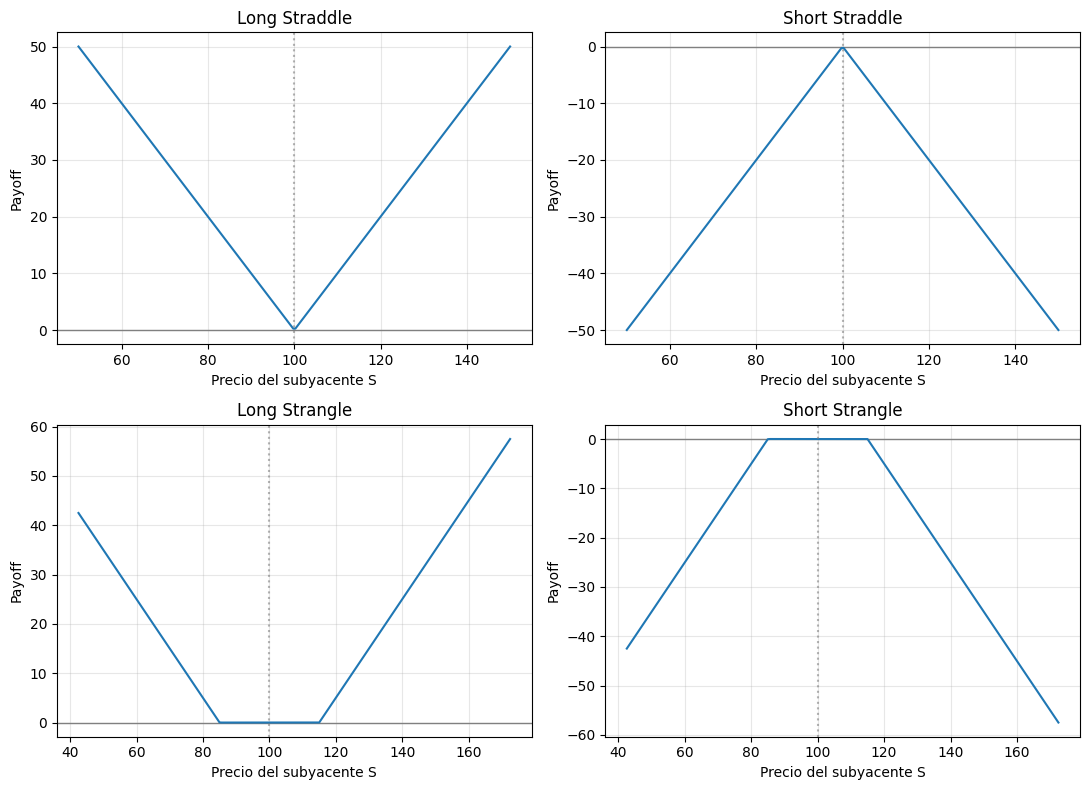

Precio long straddle: 14.051021601519722
Precio long strangle: 4.096332931408805


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_payoff(payoff_straddle, ax=axes[0, 0], title='Long Straddle', K=K)
plot_payoff(payoff_short_straddle, ax=axes[0, 1], title='Short Straddle', K=K)
plot_payoff(payoff_strangle, ax=axes[1, 0], title='Long Strangle', K1=K_call, K2=K_put)
plot_payoff(payoff_short_strangle, ax=axes[1, 1], title='Short Strangle', K1=K_call, K2=K_put)
for ax in axes.ravel():
    ax.axvline(S0, color='gray', ls=':', alpha=0.6)
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Precio long straddle:', precio_estrategia_nombre('straddle', S0, T, r, sigma, div, K=K))
print('Precio long strangle:', precio_estrategia_nombre(
    'strangle', S0, T, r, sigma, div, K1=K_call, K2=K_put))


## 2) Iron Condor e Iron Butterfly

Venta de volatilidad **con alas** (riesgo acotado):
- **Iron Condor**: short put spread + short call spread (cuatro strikes).
- **Iron Butterfly**: short straddle + alas (tres strikes).

Ganancia máxima = crédito neto si $S$ queda en el cuerpo.


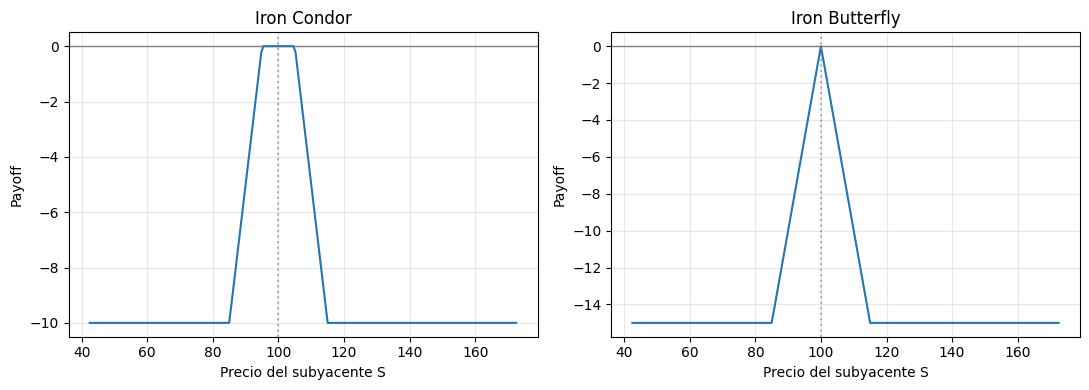

Iron Condor: -5.62411981074464


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_payoff(payoff_iron_condor, ax=axes[0], title='Iron Condor',
            K1=K1, K2=K2, K3=K3, K4=K4)
plot_payoff(payoff_iron_butterfly, ax=axes[1], title='Iron Butterfly',
            K1=K1, K2=K, K3=K4)
for ax in axes:
    ax.axvline(S0, color='gray', ls=':', alpha=0.6)
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Iron Condor:', precio_estrategia_nombre(
    'iron_condor', S0, T, r, sigma, div, K1=K1, K2=K2, K3=K3, K4=K4))


## 3) Covered Call y Protective Put

Sobre un **stock** que ya tenés (o comprás):
- **Covered Call**: long stock + short call. Genera prima; limita upside.
- **Protective Put**: long stock + long put. Seguro a la baja (caso Eje 1c).


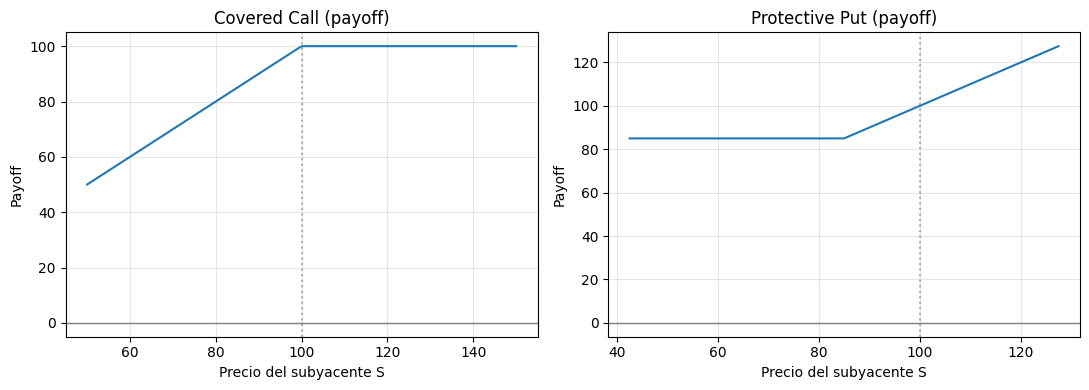

Covered call (precio neto estrategia): -8.26001519934323
Protective put: 1.1898641542111594


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_payoff(payoff_covered_call, ax=axes[0], title='Covered Call (payoff)', K=K)
plot_payoff(payoff_protective_put, ax=axes[1], title='Protective Put (payoff)', K=K1)
for ax in axes:
    ax.axvline(S0, color='gray', ls=':', alpha=0.6)
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Covered call (precio neto estrategia):',
      precio_estrategia_nombre('covered_call', S0, T, r, sigma, div, K=K))
print('Protective put:',
      precio_estrategia_nombre('protective_put', S0, T, r, sigma, div, K=K1))


## 4) Collar

Long stock + long put $K_1$ + short call $K_2$ ($K_1<K_2$).  
Acota banda de resultados: piso (put) financiado en parte con la call vendida.


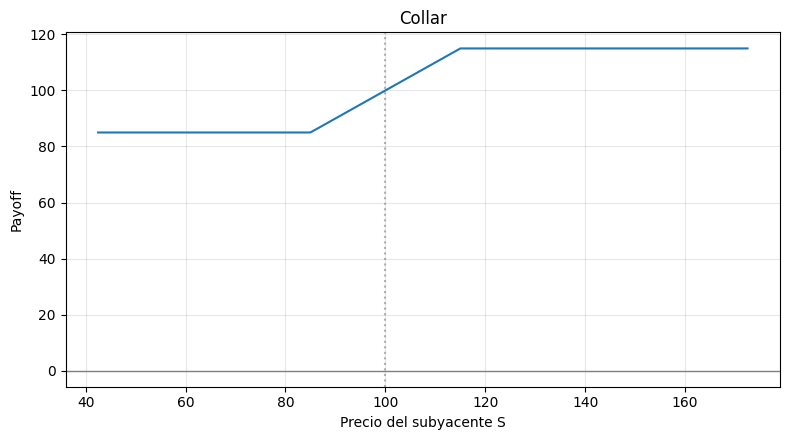

Collar: -1.7166046229864858


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_payoff(payoff_collar, ax=ax, title='Collar', K1=K1, K2=K4)
ax.axvline(S0, color='gray', ls=':', alpha=0.6)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Collar:', precio_estrategia_nombre('collar', S0, T, r, sigma, div, K1=K1, K2=K4))


## Resumen

| Estrategia | Vista típica | Riesgo |
|------------|--------------|--------|
| Long straddle/strangle | Alta vol | Débito; pierde si no se mueve |
| Short / iron | Baja vol | Crédito; colas (acotadas en iron) |
| Covered call | Lateral/leve alcista | Upside limitado |
| Protective put | Alcista con seguro | Costo de prima |
| Collar | Rango definido | Piso y techo |

**En clase:** comparar payoffs en la webapp (*Payoffs y Estrategias*) y, con market data, armar un iron/condor real en *Market Data Pricing* (Clases 3–4).
